In [23]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath("../src"))

from scraper import scrape_goodreads_lists, save_books_to_csv
from api_client import fetch_api_books, enrich_scraped_books
from cleaner import clean_data

from eda import (
    plot_rating_distribution,
    plot_popularity_distribution,
    plot_popularity_vs_rating,
    plot_page_count_distribution,
    plot_top_authors,
)

## Scraping Phase

In [ ]:
list_urls = [
    "https://www.goodreads.com/list/show/7359.Best_programming_books",
    "https://www.goodreads.com/list/show/71526.To_Read_for_Programmers",
    "https://www.goodreads.com/list/show/2205.Essential_Books_of_Computer_Science",
    "https://www.goodreads.com/list/show/93209.Computer_Science_and_Programming",
    "https://www.goodreads.com/list/show/8112.software_development",
    "https://www.goodreads.com/list/show/134947.Best_Python_programming_books",
    "https://www.goodreads.com/list/show/24494.Best_JavaScript_Books",
    "https://www.goodreads.com/list/show/33580.Software_Architecture_Books",
    "https://www.goodreads.com/list/show/161439.Best_Books_On_Software_Architecture_And_Design",
    "https://www.goodreads.com/list/show/110191.System_Design",
    "https://www.goodreads.com/list/show/44146.Clean_Code",
    "https://www.goodreads.com/list/show/134449.Microservices_Books"
]

scraped_books = scrape_goodreads_lists(list_urls, target_limit=500)
scraped_df = pd.DataFrame(scraped_books)
print(f"Scraped {len(scraped_df)} books.")
scraped_df.head()

In [ ]:
save_books_to_csv(scraped_books, "../data/scraped_books_raw.csv")
enrich_scraped_books("../data/scraped_books_raw.csv", "../data/scraped_books.csv")

In [ ]:
scraped_enriched_df = pd.read_csv("../data/scraped_books.csv")
scraped_enriched_df.head()

## API Phase

In [ ]:
api_output_path = "../data/api_books.csv"
fetch_api_books(api_output_path)
api_df = pd.read_csv(api_output_path)
print(f"Sourced {len(api_df)} books via Open Library API.")
api_df.head()

## Cleaning

In [13]:
clean_data()

cleaned_df = pd.read_csv("../data/cleaned_books.csv")
print(f"Total books: {len(cleaned_df)}")
cleaned_df.head()

Data Cleaned Successfully
Total books: 983


,title,raw_title,author,avg_rating,ratings_count,cover_url,details_url,page_count,genres,description,source
0,How to Build a Billion Dollar App,How to Build a Billion Dollar App,George Berkowski,5.0,1,https://covers.openlibrary.org/b/id/8407360-L.jpg,https://openlibrary.org/works/OL19090197W,480,"Development, Application software, Internet so...",No description available.,open_library_api
1,Java how to program--early objects,Java how to program--early objects,Paul J. Deitel,5.0,1,https://covers.openlibrary.org/b/id/15111749-L...,https://openlibrary.org/works/OL19543270W,1250,"Java (computer program language), Computer pro...",No description available.,open_library_api
2,Door duisternis tot licht,Door duisternis tot licht,Kartini Raden Adjeng,5.0,1,https://covers.openlibrary.org/b/id/1554059-L.jpg,https://openlibrary.org/works/OL1628788W,310,"Correspondence, Feminists, Social conditions, ...","Collection of letters of Kartini, a pioneer of...",open_library_api
3,Fundamentals of Programming using Java,Fundamentals of Programming using Java,Edward Currie,5.0,1,https://covers.openlibrary.org/b/id/2031875-L.jpg,https://openlibrary.org/works/OL9029736W,264,"Java (computer program language), Computer pro...",No description available.,open_library_api
4,Python,Python,Mark Lutz,5.0,2,https://covers.openlibrary.org/b/id/988215-L.jpg,https://openlibrary.org/works/OL2784127W,158,"Python (Computer program language), Python (La...","<p>Python is optimized for quality, productivi...",open_library_api


## Exploratory Data Analysis

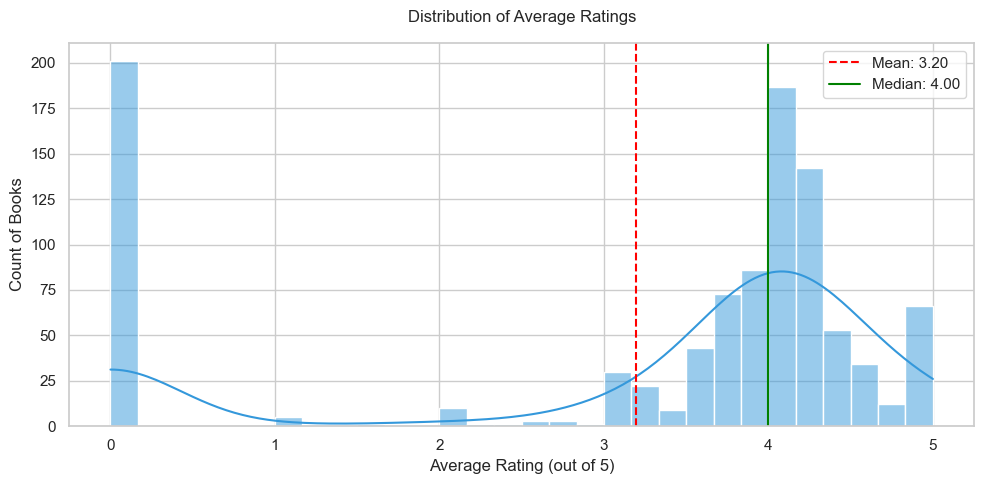

In [16]:
plot_rating_distribution(cleaned_df)

/opt/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


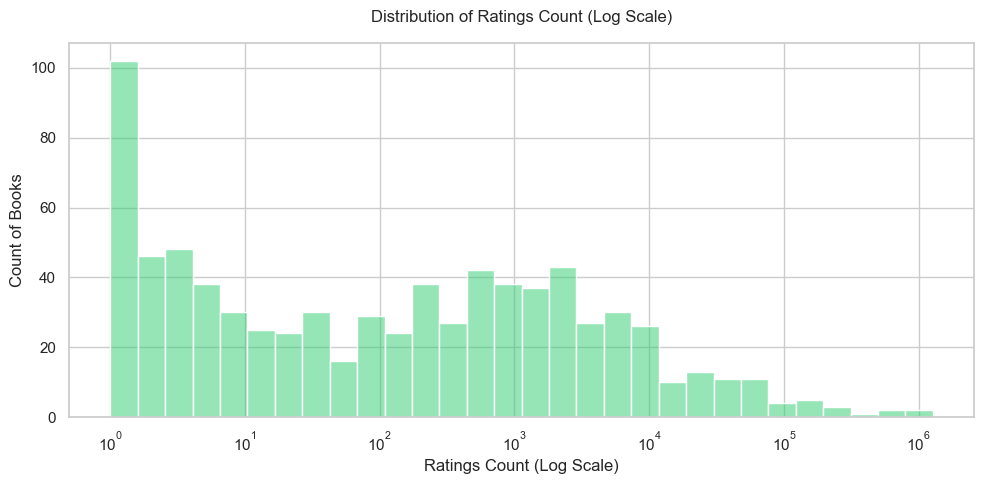

In [27]:
plot_popularity_distribution(cleaned_df)

/opt/miniconda3/lib/python3.13/site-packages/seaborn/regression.py:315: RuntimeWarning: divide by zero encountered in log
  grid = np.c_[np.ones(len(grid)), np.log(grid)]
/opt/miniconda3/lib/python3.13/site-packages/seaborn/regression.py:318: RuntimeWarning: divide by zero encountered in log
  _x = np.c_[_x[:, 0], np.log(_x[:, 1])]
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


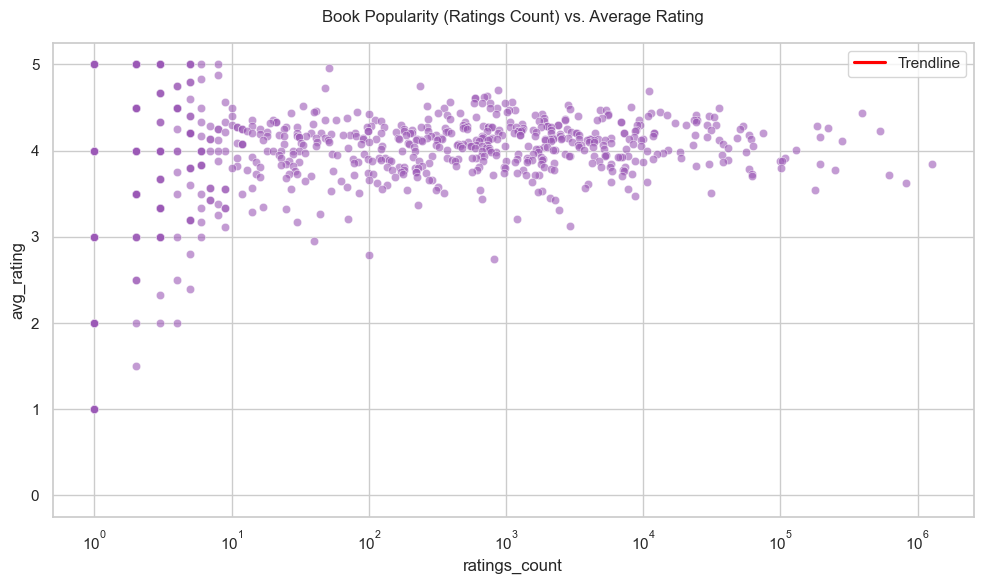

In [26]:
plot_popularity_vs_rating(cleaned_df)

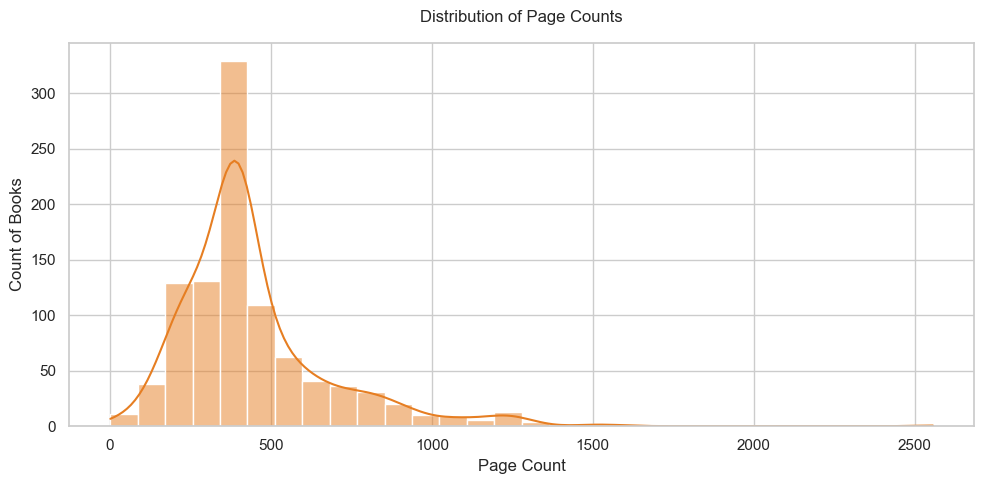

Page Count Summary Statistics:
count     983.000000
mean      444.387589
std       241.155571
min         1.000000
25%       305.000000
50%       394.000000
75%       502.500000
max      2557.000000
Name: page_count, dtype: float64


In [25]:
plot_page_count_distribution(cleaned_df)

/Users/bibo/Desktop/Desktop/Data Analytics Bootcamp/Project/book-recommendation-browser/book-recommendation-browser/src/eda.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors_count.values, y=top_authors_count.index, ax=axes[0], palette='Blues_r')
/Users/bibo/Desktop/Desktop/Data Analytics Bootcamp/Project/book-recommendation-browser/book-recommendation-browser/src/eda.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rated_authors, x='avg_rating', y='author', ax=axes[1], palette='Oranges_r')


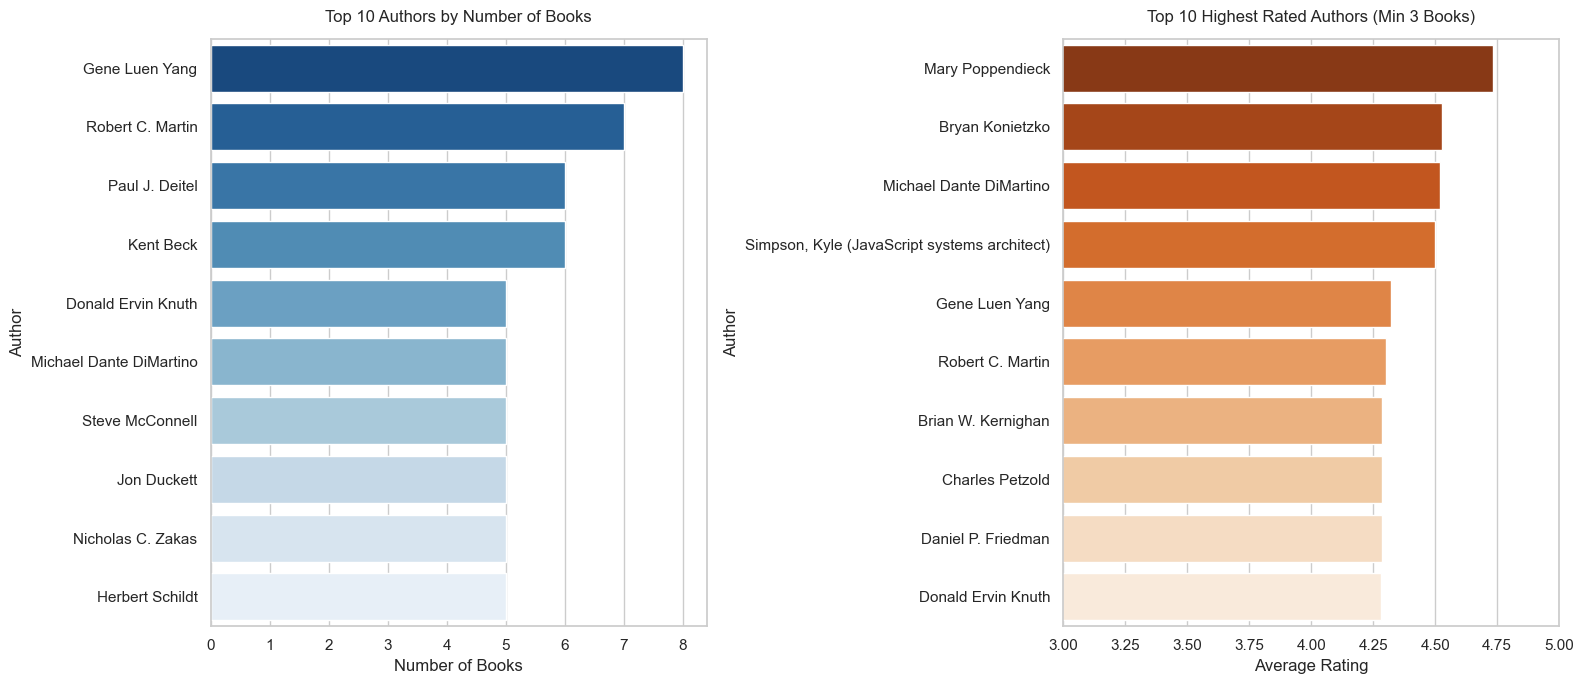

In [24]:
plot_top_authors(cleaned_df)